In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../artifacts/raw/data.csv")

In [3]:
df.head()

,Patient_ID,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,...,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status,Survival_Prediction
0,1,UK,77,M,Localized,69,No,No,Yes,Overweight,...,Yes,No,54413,50,5,Urban,Developed,Moderate,Insured,Yes
1,2,UK,59,M,Localized,33,No,No,No,Overweight,...,Yes,No,76553,37,25,Urban,Developing,High,Uninsured,Yes
2,3,Japan,66,M,Regional,17,No,Yes,No,Normal,...,Yes,No,62805,54,27,Urban,Developed,Moderate,Uninsured,No
3,4,USA,83,M,Regional,14,No,No,No,Obese,...,Yes,No,89393,45,11,Urban,Developed,Moderate,Insured,Yes
4,5,France,66,M,Localized,34,No,Yes,No,Normal,...,Yes,No,66425,15,27,Urban,Developing,High,Insured,Yes


In [4]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'Cancer_Stage',
       'Tumor_Size_mm', 'Family_History', 'Smoking_History',
       'Alcohol_Consumption', 'Obesity_BMI', 'Diet_Risk', 'Physical_Activity',
       'Diabetes', 'Inflammatory_Bowel_Disease', 'Genetic_Mutation',
       'Screening_History', 'Early_Detection', 'Treatment_Type',
       'Survival_5_years', 'Mortality', 'Healthcare_Costs',
       'Incidence_Rate_per_100K', 'Mortality_Rate_per_100K', 'Urban_or_Rural',
       'Economic_Classification', 'Healthcare_Access', 'Insurance_Status',
       'Survival_Prediction'],
      dtype='object')

In [5]:
df.isnull().sum()

Patient_ID                    0
Country                       0
Age                           0
Gender                        0
Cancer_Stage                  0
Tumor_Size_mm                 0
Family_History                0
Smoking_History               0
Alcohol_Consumption           0
Obesity_BMI                   0
Diet_Risk                     0
Physical_Activity             0
Diabetes                      0
Inflammatory_Bowel_Disease    0
Genetic_Mutation              0
Screening_History             0
Early_Detection               0
Treatment_Type                0
Survival_5_years              0
Mortality                     0
Healthcare_Costs              0
Incidence_Rate_per_100K       0
Mortality_Rate_per_100K       0
Urban_or_Rural                0
Economic_Classification       0
Healthcare_Access             0
Insurance_Status              0
Survival_Prediction           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(167497, 28)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167497 entries, 0 to 167496
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   Patient_ID                  167497 non-null  int64 
 1   Country                     167497 non-null  object
 2   Age                         167497 non-null  int64 
 3   Gender                      167497 non-null  object
 4   Cancer_Stage                167497 non-null  object
 5   Tumor_Size_mm               167497 non-null  int64 
 6   Family_History              167497 non-null  object
 7   Smoking_History             167497 non-null  object
 8   Alcohol_Consumption         167497 non-null  object
 9   Obesity_BMI                 167497 non-null  object
 10  Diet_Risk                   167497 non-null  object
 11  Physical_Activity           167497 non-null  object
 12  Diabetes                    167497 non-null  object
 13  Inflammatory_Bowel_Disease  1

In [9]:
df.describe()

,Patient_ID,Age,Tumor_Size_mm,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K
count,167497.000000,167497.00000,167497.000000,167497.000000,167497.000000,167497.000000
mean,83749.000000,69.20078,42.005708,72452.168099,34.531562,17.023875
std,48352.363357,11.87247,21.672206,27402.779597,14.447970,7.208766
min,1.000000,30.00000,5.000000,25000.000000,10.000000,5.000000
25%,41875.000000,59.00000,23.000000,48760.000000,22.000000,11.000000
50%,83749.000000,69.00000,42.000000,72344.000000,35.000000,17.000000
75%,125623.000000,79.00000,61.000000,96227.000000,47.000000,23.000000
max,167497.000000,89.00000,79.000000,119999.000000,59.000000,29.000000


#### Visualizations

Text(0.5, 1.0, 'Cancer Stage Vs Survival_5_Years')

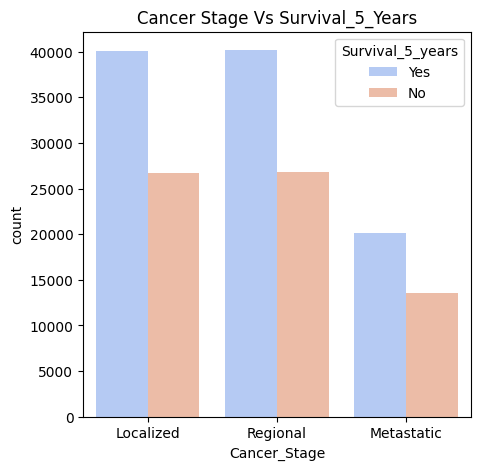

In [10]:
plt.figure(figsize=(5,5))
sns.countplot(x="Cancer_Stage",hue="Survival_5_years",data=df, palette="coolwarm")
plt.title("Cancer Stage Vs Survival_5_Years")

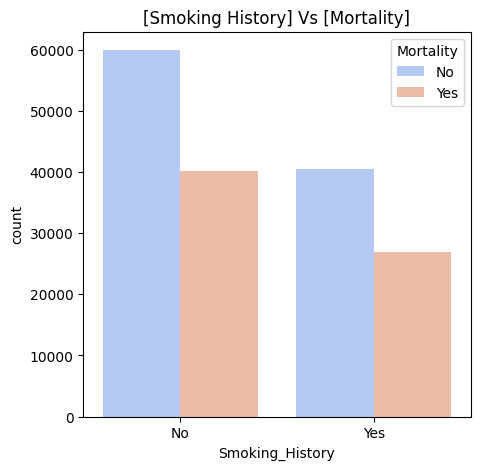

In [11]:
plt.figure(figsize=(5,5))
sns.countplot(x="Smoking_History",hue="Mortality",data=df, palette="coolwarm")
plt.title("[Smoking History] Vs [Mortality]")
plt.show()

DATA PROCESSING

In [12]:
df = df.drop(columns=["Patient_ID"])

In [13]:
df.shape

(167497, 27)

In [14]:
X = df.drop(columns=["Survival_Prediction"])
Y = df["Survival_Prediction"]

In [15]:
categorical_cols = X.select_dtypes(include=["object"])

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [18]:
X.head()

,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,Diet_Risk,...,Treatment_Type,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status
0,14,77,1,0,69,0,0,1,2,1,...,1,1,0,54413,50,5,1,0,2,0
1,14,59,1,0,33,0,0,0,2,2,...,0,1,0,76553,37,25,1,1,0,1
2,8,66,1,2,17,0,1,0,0,1,...,0,1,0,62805,54,27,1,0,2,1
3,15,83,1,2,14,0,0,0,1,0,...,3,1,0,89393,45,11,1,0,2,0
4,4,66,1,0,34,0,1,0,0,1,...,3,1,0,66425,15,27,1,1,0,0


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [21]:
from sklearn.feature_selection import chi2,SelectKBest

In [22]:
X_cat = X_train.select_dtypes(include=["int64","float64"])
chi2_selector = SelectKBest(score_func=chi2,k="all")
chi2_selector.fit(X_cat,y_train)

,score_func,<function chi...00224913A7A30>
,k,'all'


In [24]:
chi2_scores = pd.DataFrame({
    "Feature":X_cat.columns,
    "Chi2 Score": chi2_selector.scores_
}).sort_values(by="Chi2 Score",ascending=False)

In [25]:
chi2_scores

,Feature,Chi2 Score
19,Healthcare_Costs,2097.430133
4,Tumor_Size_mm,7.971461
16,Treatment_Type,4.987144
11,Diabetes,2.103967
21,Mortality_Rate_per_100K,1.963077
25,Insurance_Status,1.464241
3,Cancer_Stage,1.281849
14,Screening_History,1.159519
0,Country,0.883425
24,Healthcare_Access,0.713346


In [38]:
top_features = chi2_scores.head(5)["Feature"].tolist()
top_features

['Healthcare_Costs',
 'Tumor_Size_mm',
 'Treatment_Type',
 'Diabetes',
 'Mortality_Rate_per_100K']

In [39]:
X = X[top_features]

In [41]:
X.shape

(167497, 5)

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,stratify=Y)

In [43]:
X_train.shape

(133997, 5)

In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###### Model Building

In [46]:
from sklearn.ensemble import GradientBoostingClassifier

In [47]:
gb = GradientBoostingClassifier(n_estimators = 100, learning_rate=0.1, max_depth = 3, random_state=42)

In [48]:
gb.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [49]:
y_pred = gb.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.5994029850746269

In [54]:
from sklearn.metrics import roc_auc_score, classification_report

In [56]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

          No       0.38      0.00      0.00     13412
         Yes       0.60      1.00      0.75     20088

    accuracy                           0.60     33500
   macro avg       0.49      0.50      0.38     33500
weighted avg       0.51      0.60      0.45     33500



In [57]:
roc_auc = roc_auc_score(y_test,y_pred)

ValueError: could not convert string to float: 'Yes'